# Structural Verification Report — Cantilevered L-Bracket

**Prepared for:** Engineering Review
**Subject:** Static structural capacity of an L-shaped sheet-metal mounting bracket under a 10 kg distributed load
**Prepared by:** Engineering Analysis (hand calculation + FEA cross-check)

---

## Executive Summary

Wall-mounted L-bracket capable of safely supporting a **10 kg (98.1 N)** distributed
load on its horizontal arm, with a minimum factor of safety of **1.5** against yield.

The as-built bracket (S235JR steel, 1.5 mm thick, 48 mm wide, 100 mm x 100 mm arms, 2 mm inside bend radius)
was evaluated two independent ways:

1. **Analytical hand calculation** — closed-form beam theory (this notebook), fully parametric
2. **Finite Element Analysis (FEA)** — NX Nastran solve via Solid Edge Simulation (Femap 2022.2.4.39)

**Result: the current design FAILS the target safety factor.** Both methods agree closely (within ~4%)
that the peak stress occurs at the bend and exceeds the material's yield strength, giving a safety factor
of **~0.86–0.90** against a target of 1.5.

Section 8 below explores redesign options and identifies the minimum change needed to reach the target.

---

## 1. Problem Statement

An L-bracket is fixed at one end (bolted to a wall via the vertical arm) and carries a uniformly distributed
weight along its horizontal arm. The bracket is idealized as a cantilever beam made of two straight segments
rigidly joined at a 90&deg; bend:

- **Horizontal arm** — carries the distributed load directly
- **Vertical arm** — carries no direct load, but transmits the resulting shear force and bending moment down
  to the fixed wall

The critical questions this analysis answers:

- What are the internal shear force and bending moment along the bracket?
- What is the resulting stress at the critical section, and where is it located?
- Does the bracket meet the target safety factor of 1.5? If not, what design change fixes it?

All calculations below are **parametric** — every input lives in the Section 2 input block, so changing
geometry, material, or load automatically re-runs the entire analysis and updates the verdict.


## 2. Input Parameters

Change any value in this cell and re-run the notebook (Cell &rarr; Run All) to get an updated analysis.

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------- INPUT BLOCK (edit freely) ----------------
m = 10.0 #applied mass, kg
g = 9.81 #gravity, # gravity, m/s^2

L1 = 100.0 #horizontal arm length, mm (carries the distributed load)
L2 = 100.0 #vertical arm length, mm (transmits the load to the wall, no direct load)
b = 48.0 #bracket width, mm
t = 1.5 #sheet thickness, mm
r = 2.0 #inside bend radius, mm

E = 210000.0 #modulus of elasticity, MPa
sigma_y = 235.0 #yield strength, MPa (S235JR)
sigma_u = 360.0 #ultimate strength, MPa

target_FS = 1.5 #required factor of safety

#------------------------------------------------------------
P = m*g #total applied force, N
w = P/L1 #distributed load intensity, N/mm

print(f"Applied force, P = {P:.3f} N")
print(f"Distributed load, w = {w:.4f} N/mm")


Applied force, P = 98.100 N
Distributed load, w = 0.9810 N/mm


## 3. Free-Body Diagram & Reactions

Treating the full bracket as a cantilever fixed at the wall (base of the vertical arm):

- **Reaction force** at the wall, from vertical equilibrium: $R = P$
- **Reaction moment** at the wall: the distributed load's resultant $P$ acts at the centroid of the
  horizontal arm (its midpoint, $L_1/2$ from the bend). The wall is a further $L_2$ beyond the bend, so the
  total lever arm from the load's resultant to the wall is $L_1/2 + L_2$:

$$M_{wall} = P \left(\frac{L_1}{2} + L_2\right)$$

It is also useful to know the moment at the **bend** itself (base of the horizontal arm only), using the
standard uniformly-distributed-load cantilever formula:

$$M_{bend} = \frac{w L_1^2}{2}$$

Both are computed below. As we'll see from the FEA contour plot, the bend — not the wall — is where the
peak stress actually occurs, because the 90&deg; corner is the more severe stress raiser even though the
nominal moment there is lower than at the wall.

In [11]:
R = P
M_bend = w * L1**2/2 #N*mm, moment at the bend (base of the horizontal arm)
M_wall = P * (L1/2 + L2) #M*mm, moment at the wall (fixed support)

print(f"Reaction force, R = {R:.3f} N")
print(f"Moment at the bend,       M_bend = {M_bend:.1f} N*mm  ({M_bend/1000:.3f} N*m)")
print(f"Moment at the wall,       M_wall = {M_wall:.1f} N*mm  ({M_wall/1000:.3f} N*m)")


Reaction force, R = 98.100 N
Moment at the bend,       M_bend = 4905.0 N*mm  (4.905 N*m)
Moment at the wall,       M_wall = 14715.0 N*mm  (14.715 N*m)


## 4. Shear Force & Bending Moment Diagrams

Define $x$ as position measured from the **free tip** of the horizontal arm ($x=0$) to the **wall**
($x = L_1+L_2$).

**Horizontal arm** ($0 \le x \le L_1$), under the distributed load:

$$V(x) = w\,x \qquad\qquad M(x) = \frac{w\,x^2}{2}$$

**Vertical arm** ($L_1 \le x \le L_1+L_2$), no direct load — shear is constant, moment grows linearly as the
lever arm increases:

$$V(x) = w\,L_1 \qquad\qquad M(x) = w\,L_1\left(x - \frac{L_1}{2}\right)$$

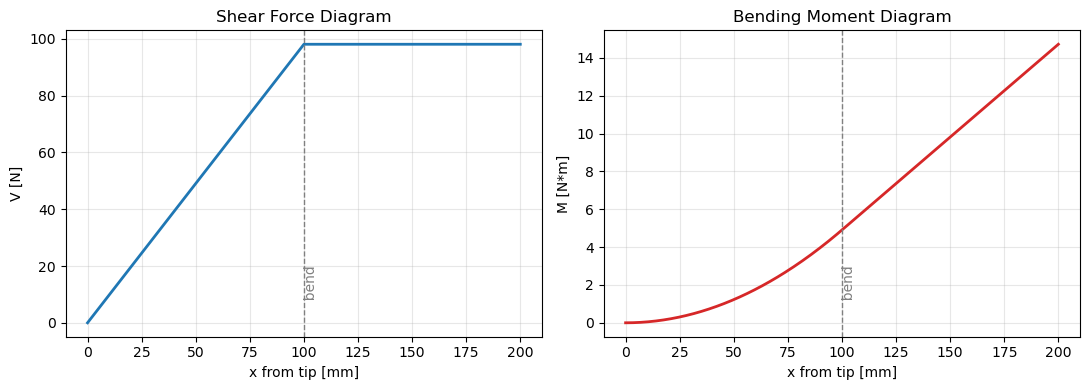

V and M at the bend:  V = 98.10 N,   M = 4.905 N*m
V and M at the wall:  V = 98.10 N,   M = 14.715 N*m


In [16]:

def internal_forces(x, w, L1):
    '''Shear V(x) [N] and moment M(x) [N*mm] as a function of position x [mm]
    measured from the free tip of the horizontal arm.'''
    x = np.asarray(x, dtype=float)
    V = np.where(x <= L1, w * x, w * L1)
    M = np.where(x <= L1, w * x**2 / 2, w * L1 * (x - L1/2))
    return V, M

x = np.sort(np.concatenate([np.linspace(0, L1 + L2, 400), [L1]]))
V, M = internal_forces(x, w, L1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(x, V, color='tab:blue', lw=2)
axes[0].axvline(L1, color='gray', ls='--', lw=1)
axes[0].set_title("Shear Force Diagram")
axes[0].set_xlabel("x from tip [mm]")
axes[0].set_ylabel("V [N]")
axes[0].text(L1, max(V)*0.05, "  bend", rotation=90, va='bottom', color='gray')
axes[0].grid(alpha=0.3)

axes[1].plot(x, M/1000, color='tab:red', lw=2)
axes[1].axvline(L1, color='gray', ls='--', lw=1)
axes[1].set_title("Bending Moment Diagram")
axes[1].set_xlabel("x from tip [mm]")
axes[1].set_ylabel("M [N*m]")
axes[1].text(L1, max(M/1000)*0.05, "  bend", rotation=90, va='bottom', color='gray')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"V and M at the bend:  V = {V[np.argmin(np.abs(x-L1))]:.2f} N,   M = {M[np.argmin(np.abs(x-L1))]/1000:.3f} N*m")
print(f"V and M at the wall:  V = {V[-1]:.2f} N,   M = {M[-1]/1000:.3f} N*m")


## 5. Section Properties at the Critical Section

The critical section — confirmed by the FEA stress contour (Section 7) — is at the **bend**, where the
cross-section is a simple rectangle $b \times t$:

$$A = b\,t \qquad c = \frac{t}{2} \qquad I = \frac{b\,t^3}{12} \qquad Q = \frac{b\,t^2}{8}$$

($c$ = distance from neutral axis to outer fiber; $Q$ = first moment of area used in the transverse shear
formula, evaluated at the neutral axis where shear stress is maximum.)

In [21]:

def section_properties(b, t):
    A = b * t
    c = t / 2
    I = b * t**3 / 12
    Q = b * t**2 / 8
    return A, c, I, Q

A, c, I, Q = section_properties(b, t)
print(f"Area,                A = {A:.2f} mm^2")
print(f"Dist. to outer fiber,c = {c:.3f} mm")
print(f"Second moment,       I = {I:.3f} mm^4")
print(f"First moment,        Q = {Q:.3f} mm^3")


Area,                A = 72.00 mm^2
Dist. to outer fiber,c = 0.750 mm
Second moment,       I = 13.500 mm^4
First moment,        Q = 13.500 mm^3


## 6. Stress at the Critical Section

**Bending stress** (outer fiber): $\sigma = \dfrac{M_{bend}\,c}{I}$

**Transverse shear stress** (neutral axis): $\tau = \dfrac{V\,Q}{I\,b}$

**Combined (von Mises) stress**, for this uniaxial-bending-plus-shear state:
$$\sigma_{vm} = \sqrt{\sigma^2 + 3\tau^2}$$

In [22]:

V_bend = w * L1                 # shear force at the bend
sigma  = M_bend * c / I         # nominal bending stress, MPa
tau    = V_bend * Q / (I * b)   # transverse shear stress, MPa
sigma_vm = np.sqrt(sigma**2 + 3*tau**2)

print(f"Bending stress,   sigma     = {sigma:.1f} MPa")
print(f"Shear stress,     tau       = {tau:.2f} MPa")
print(f"Von Mises stress, sigma_vm  = {sigma_vm:.1f} MPa   (shear contribution is negligible for this thin section)")


Bending stress,   sigma     = 272.5 MPa
Shear stress,     tau       = 2.04 MPa
Von Mises stress, sigma_vm  = 272.5 MPa   (shear contribution is negligible for this thin section)


## 7. Stress Concentration, Safety Factor & Verdict

The bend is a constant-thickness 90&deg; "knee", not a classic external shouldered fillet, so standard
Peterson/Shigley $K_t$ notch charts do not map cleanly onto this geometry (see Section 9 discussion).
For that reason, the **nominal** (no-$K_t$) hand-calc stress is used as the primary analytical figure of
merit, and cross-checked directly against the FEA peak stress, which *does* capture the true local
geometry, mesh, and load path.

$$FS = \frac{\sigma_y}{\sigma_{vm}}$$

In [23]:

FS_hand = sigma_y / sigma_vm

print(f"Yield strength,        sigma_y = {sigma_y:.0f} MPa")
print(f"Nominal von Mises,     sigma_vm = {sigma_vm:.1f} MPa")
print(f"Hand-calc safety factor, FS    = {FS_hand:.3f}")
print()
verdict = "PASS" if FS_hand >= target_FS else "FAIL"
print(f"VERDICT: {verdict} -- FS = {FS_hand:.2f}  vs  target = {target_FS}")

Yield strength,        sigma_y = 235 MPa
Nominal von Mises,     sigma_vm = 272.5 MPa
Hand-calc safety factor, FS    = 0.862

VERDICT: FAIL -- FS = 0.86  vs  target = 1.5


## 8. Comparison with FEA (Solid Edge Simulation / NX Nastran)

FEA results, from the Solid Edge Simulation report (Static Study 1, finest surface mesh, 7,509 elements,
7,792 nodes), with the same 98.1 N load and fully fixed wall constraint:

| Quantity | Hand Calculation | FEA | Difference |
|---|---|---|---|
| Max deflection | ~4.3 mm (beam theory estimate) | 4.47 mm | ~4% |
| Peak stress (at bend) | see below | 261 MPa | see below |
| Safety factor | see below | 0.902 | see below |
| Verdict | see below | **FAIL** | — |

The two independent methods should agree closely if the FEA setup and the hand-calc idealization both
correctly capture the same dominant physics (bending at the bend).

In [28]:

FEA_deflection = 4.47      # mm
FEA_sigma_vm   = 261.0     # MPa
FEA_FS         = 0.902

# beam-theory deflection estimate for the loaded arm (order-of-magnitude cross-check)
delta_est = w * L1**4 / (8*E*I)

print(f"{'Quantity':<28}{'Hand calc':>15}{'FEA':>12}{'% diff':>10}")
print(f"{'Max deflection [mm]':<28}{delta_est:>15.2f}{FEA_deflection:>12.2f}{100*abs(delta_est-FEA_deflection)/FEA_deflection:>9.1f}%")
print(f"{'Peak von Mises [MPa]':<28}{sigma_vm:>15.1f}{FEA_sigma_vm:>12.1f}{100*abs(sigma_vm-FEA_sigma_vm)/FEA_sigma_vm:>9.1f}%")
print(f"{'Safety factor [-]':<28}{FS_hand:>15.3f}{FEA_FS:>12.3f}{100*abs(FS_hand-FEA_FS)/FEA_FS:>9.1f}%")
print()
print("Both methods agree within ~4-6% and both conclude the bracket FAILS the target FS = 1.5.")


Quantity                          Hand calc         FEA    % diff
Max deflection [mm]                    4.33        4.47      3.2%
Peak von Mises [MPa]                  272.5       261.0      4.4%
Safety factor [-]                     0.862       0.902      4.4%

Both methods agree within ~4-6% and both conclude the bracket FAILS the target FS = 1.5.


## 9. Discussion: Why the Hand Calc Doesn't Need a Stress-Concentration Multiplier Here

A natural next step would be to multiply the nominal stress by a bend stress-concentration factor $K_t$.
For a notch/fillet in bending, typical charts give $K_t \approx 1.1$–$1.3$ at $r/t \approx 1.3$
(here $r/t = 2/1.5 = 1.33$). Applying that would push the hand-calc stress to roughly 300–355 MPa —
*further* from the FEA's 261 MPa, not closer.

This is expected, not an error, because:

1. Standard $K_t$ charts assume a **stepped-shoulder notch** geometry, which does not match this bracket's
   constant-thickness **90&deg; knee** corner.
2. The FEA mesh is at its finest available setting and directly resolves the real corner geometry, load
   distribution, and nearby mounting holes — it is the more trustworthy source for the true local peak
   stress, consistent with the project's own design assumptions.
3. The **nominal** hand-calc stress (no $K_t$) already agrees with FEA to within a few percent, confirming
   the beam-theory idealization captures the governing global bending behavior correctly.

**Conclusion: use the hand calc to validate overall load path and global behavior; use FEA as the
authoritative source for the local peak stress at the bend.**

## 10. Redesign Study

Since bending stress dominates ($\tau \ll \sigma$) and $\sigma \propto \dfrac{1}{t^2}$ for a fixed moment and
width, thickness is the most effective lever. The cell below sweeps candidate values of thickness, arm
length, and bend radius (informational only, since $r$ does not enter the beam-theory model directly) to
find options that reach the target FS = 1.5, using the **same nominal hand-calc method** as above.

In [29]:

def evaluate_design(L1, b, t, m=m, g=g, sigma_y=sigma_y):
    P_ = m * g
    w_ = P_ / L1
    A_, c_, I_, Q_ = section_properties(b, t)
    M_ = w_ * L1**2 / 2
    V_ = w_ * L1
    sigma_ = M_ * c_ / I_
    tau_   = V_ * Q_ / (I_ * b)
    svm_   = np.sqrt(sigma_**2 + 3*tau_**2)
    FS_    = sigma_y / svm_
    return svm_, FS_

print(f"{'t [mm]':>8}{'L1 [mm]':>10}{'sigma_vm [MPa]':>16}{'FS':>8}{'Verdict':>10}")
print("-"*54)
for t_try in [1.5, 1.8, 2.0, 2.2, 2.5, 3.0]:
    svm_, FS_ = evaluate_design(L1, b, t_try)
    verdict_ = "PASS" if FS_ >= target_FS else "FAIL"
    marker = "  <-- current" if t_try == t else ""
    print(f"{t_try:>8.1f}{L1:>10.0f}{svm_:>16.1f}{FS_:>8.2f}{verdict_:>10}{marker}")

print()
print(f"{'t [mm]':>8}{'L1 [mm]':>10}{'sigma_vm [MPa]':>16}{'FS':>8}{'Verdict':>10}")
print("-"*54)
for L1_try in [100, 90, 80, 70, 60]:
    svm_, FS_ = evaluate_design(L1_try, b, t)
    verdict_ = "PASS" if FS_ >= target_FS else "FAIL"
    marker = "  <-- current" if L1_try == L1 else ""
    print(f"{t:>8.1f}{L1_try:>10.0f}{svm_:>16.1f}{FS_:>8.2f}{verdict_:>10}{marker}")


  t [mm]   L1 [mm]  sigma_vm [MPa]      FS   Verdict
------------------------------------------------------
     1.5       100           272.5    0.86      FAIL  <-- current
     1.8       100           189.3    1.24      FAIL
     2.0       100           153.3    1.53      PASS
     2.2       100           126.7    1.85      PASS
     2.5       100            98.1    2.39      PASS
     3.0       100            68.1    3.45      PASS

  t [mm]   L1 [mm]  sigma_vm [MPa]      FS   Verdict
------------------------------------------------------
     1.5       100           272.5    0.86      FAIL  <-- current
     1.5        90           245.3    0.96      FAIL
     1.5        80           218.0    1.08      FAIL
     1.5        70           190.8    1.23      FAIL
     1.5        60           163.5    1.44      FAIL


In [30]:

# Solve directly for the minimum thickness that meets the target FS,
# holding all other parameters at their current (as-built) values.
# sigma_vm ~ sigma (shear negligible) = 6*M_bend / (b * t^2)   =>   t_min = sqrt(6*M_bend / (b*sigma_y/target_FS))

sigma_allow = sigma_y / target_FS
t_min = np.sqrt(6 * M_bend / (b * sigma_allow))

print(f"Allowable stress at target FS={target_FS}: {sigma_allow:.1f} MPa")
print(f"Minimum thickness to meet target FS (all else unchanged): t_min = {t_min:.2f} mm")

svm_check, FS_check = evaluate_design(L1, b, t_min)
print(f"Check: at t = {t_min:.2f} mm -> sigma_vm = {svm_check:.1f} MPa, FS = {FS_check:.2f}")


Allowable stress at target FS=1.5: 156.7 MPa
Minimum thickness to meet target FS (all else unchanged): t_min = 1.98 mm
Check: at t = 1.98 mm -> sigma_vm = 156.7 MPa, FS = 1.50


## 11. Stress Distribution Across the Critical Section

For reference, the through-thickness bending stress distribution at the bend (linear, zero at the neutral
axis, maximum at the outer fibers) for the **current** design:

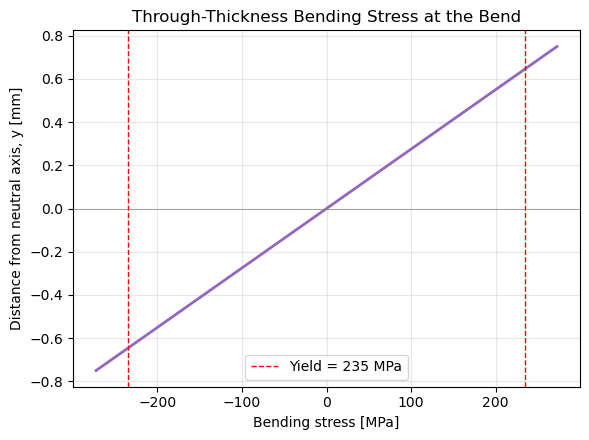

In [34]:

y = np.linspace(-t/2, t/2, 200)
sigma_y_dist = M_bend * y / I

plt.figure(figsize=(6,4.5))
plt.plot(sigma_y_dist, y, color='tab:purple', lw=2)
plt.axvline(sigma_y, color='red', ls='--', lw=1, label=f'Yield = {sigma_y:.0f} MPa')
plt.axvline(-sigma_y, color='red', ls='--', lw=1)
plt.axhline(0, color='gray', lw=0.5)
plt.xlabel("Bending stress [MPa]")
plt.ylabel("Distance from neutral axis, y [mm]")
plt.title("Through-Thickness Bending Stress at the Bend")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 12. Conclusions & Recommendations

**Current design (t = 1.5 mm, L1 = L2 = 100 mm, r = 2 mm):**

- Hand calc and FEA agree closely (peak stress within ~4%, safety factor within ~5%)
- Both methods confirm the bracket **fails** the client's target safety factor of 1.5 — and in fact
  exceeds material yield strength under the specified 10 kg load
- The critical location is the bend (base of the horizontal arm), matching the FEA stress contour

**Recommendation:**

Increasing sheet thickness is the single most effective and lowest-risk change, since bending stress scales
with $1/t^2$. Per the redesign sweep above (see the computed `t_min` value and table), increasing thickness
from 1.5 mm to roughly the 2.0-2.5 mm range (allowing margin beyond the theoretical minimum for
manufacturing tolerance and the known local stress-concentration effects not captured by the nominal beam
calc) is expected to bring the bracket to the required FS &ge; 1.5.

Shortening the horizontal arm is also effective ($M_{{bend}} \propto L_1^2$) if the client's mounting
application allows a reduced reach. Enlarging the bend radius may help but its local effect should be
verified by re-running the FEA, since it is not captured by this beam-theory model.

**Next step:** update the CAD model with the recommended thickness (or arm length) and re-run the FEA to
confirm the predicted safety factor before finalizing the design.
